# 06. Policy Learning and Treatment Targeting

So far, the causal ML section has focused on estimating heterogeneous treatment effects. Policy learning asks the next question:

> Given what we know about heterogeneous effects, who should receive the intervention?

That change sounds small, but it is a major shift. An effect-estimation project produces knowledge. A policy-learning project produces an allocation rule. The rule may need to respect budget limits, operational capacity, fairness constraints, customer experience constraints, regulatory constraints, and the risk that the estimated effects are wrong.

This notebook builds policy learning from the ground up for an industry targeting problem. We will estimate causal scores, learn treatment policies, evaluate those policies with doubly robust scores, and compare flexible policies with interpretable decision rules.

## Learning Goals

By the end of this notebook, you should be able to:

- Define an individualized treatment policy as a mapping from covariates to actions.
- Distinguish CATE estimation from policy learning.
- Write the value of a treatment policy in potential-outcomes notation.
- Translate treatment targeting into a welfare maximization problem.
- Incorporate intervention costs and capacity constraints.
- Estimate policy value using doubly robust scores.
- Learn plug-in and interpretable targeting policies from causal scores.
- Compare policies with targeting curves, policy regret, overlap diagnostics, and segment-level readouts.
- Explain why a policy should be evaluated honestly rather than judged by the same data used to choose it.

In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def top_fraction_policy(scores, fraction, require_positive=True):
    scores = np.asarray(scores)
    if fraction <= 0:
        return np.zeros(len(scores), dtype=int)
    if fraction >= 1:
        policy = np.ones(len(scores), dtype=int)
    else:
        threshold = np.quantile(scores, 1 - fraction)
        policy = (scores >= threshold).astype(int)
    if require_positive:
        policy = policy * (scores > 0).astype(int)
    return policy


def summarize_policy(name, policy, score=None):
    return {
        "policy": name,
        "treatment_rate": np.mean(policy),
        "avg_score_treated": np.nan if score is None or np.sum(policy) == 0 else np.mean(np.asarray(score)[policy == 1]),
        "n_treated": int(np.sum(policy)),
    }

## 1. From Effects to Decisions

A CATE model estimates:

$$
\tau(x) = E[Y(1) - Y(0) \mid X=x]
$$

A policy is a rule:

$$
\pi(x) \in \{0,1\}
$$

where $\pi(x)=1$ means treat the unit with covariates $x$ and $\pi(x)=0$ means do not treat.

If treatment has no cost and there are no constraints, the ideal treatment rule is simple:

$$
\pi^*(x) = 1\{\tau(x) > 0\}
$$

Industry settings are rarely that clean. Interventions have costs. Teams have limited capacity. Some decisions need to be explainable. Some customer segments may be protected by fairness, compliance, or brand-risk constraints. Policy learning is the discipline of turning causal evidence into a decision rule under those real constraints.

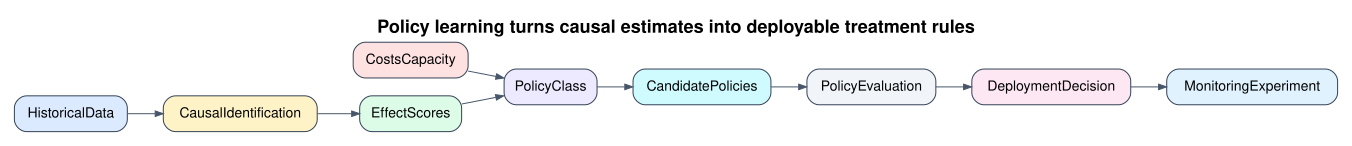

In [3]:
make_dag(
    edges=[
        ("HistoricalData", "CausalIdentification"),
        ("CausalIdentification", "EffectScores"),
        ("EffectScores", "PolicyClass"),
        ("CostsCapacity", "PolicyClass"),
        ("PolicyClass", "CandidatePolicies"),
        ("CandidatePolicies", "PolicyEvaluation"),
        ("PolicyEvaluation", "DeploymentDecision"),
        ("DeploymentDecision", "MonitoringExperiment"),
    ],
    title="Policy learning turns causal estimates into deployable treatment rules",
    node_colors={
        "HistoricalData": "#dbeafe",
        "CausalIdentification": "#fef3c7",
        "EffectScores": "#dcfce7",
        "CostsCapacity": "#fee2e2",
        "PolicyClass": "#ede9fe",
        "CandidatePolicies": "#cffafe",
        "PolicyEvaluation": "#f1f5f9",
        "DeploymentDecision": "#fce7f3",
        "MonitoringExperiment": "#e0f2fe",
    },
)

## 2. Policy Value

For a binary treatment, the potential outcome under policy $\pi$ is:

$$
Y(\pi) = \pi(X)Y(1) + (1-\pi(X))Y(0)
$$

The policy value is:

$$
V(\pi) = E[Y(\pi)]
$$

If treatment has a known unit-specific cost $c(X)$, we often care about net value:

$$
V_c(\pi) = E[\pi(X)\{Y(1)-c(X)\} + (1-\pi(X))Y(0)]
$$

Equivalently, the incremental gain over treating nobody is:

$$
G_c(\pi) = E[\pi(X)\{\tau(X)-c(X)\}]
$$

This last expression is the core of treatment targeting. Treat units where expected incremental benefit exceeds cost, subject to any constraints.

Kitagawa and Tetenov (2018) study empirical welfare maximization for treatment choice, while Athey and Wager (2021) develop policy learning methods for observational data with practical constraints. Kallus (2020) emphasizes that overlap can become a major bottleneck when policies are learned from observational data.

## 3. Running Example: Customer-Retention Targeting

Imagine a subscription business with a limited customer-success team. The team can offer an intensive retention intervention: workflow consulting, executive outreach, migration help, or dedicated onboarding support.

The business question is:

> Which accounts should receive the retention intervention next quarter?

The intervention is not free. It consumes account-manager time and may create customer fatigue. We therefore maximize net incremental value:

$$
\tau(x) - c(x)
$$

The historical data are observational. Account managers tended to intervene for high-risk, high-value, enterprise accounts. That means naive comparisons between treated and untreated accounts are confounded by the historical targeting process.

In [4]:
def simulate_retention_targeting_data(n=9000, seed=5606):
    rng = np.random.default_rng(seed)

    churn_risk = rng.beta(2.2, 2.5, n)
    product_health = rng.beta(2.6, 2.1, n)
    usage_depth = rng.normal(0, 1, n)
    log_mrr = rng.normal(4.5, 0.62, n)
    mrr_z = (log_mrr - log_mrr.mean()) / log_mrr.std()
    enterprise = rng.binomial(1, sigmoid(-0.2 + 0.9 * mrr_z + 0.5 * churn_risk), n)
    strategic_account = rng.binomial(1, sigmoid(-1.35 + 0.9 * enterprise + 0.7 * mrr_z), n)
    onboarding_gap = rng.beta(1.8, 3.2, n)
    support_tickets = rng.poisson(np.clip(0.4 + 3.0 * churn_risk - 0.9 * product_health + 0.7 * enterprise, 0.05, None))
    integration_depth = rng.poisson(np.clip(1.0 + 3.4 * product_health + 1.2 * enterprise, 0.1, None))
    region_emea = rng.binomial(1, 0.28, n)
    region_west = rng.binomial(1, 0.31, n) * (1 - region_emea)

    severe_risk = ((churn_risk > 0.78) & (product_health < 0.28)).astype(float)
    reachable_risk = churn_risk * (1 - product_health)
    high_value_need = enterprise * (churn_risk > 0.45).astype(float)

    historical_logit = (
        -1.15
        + 2.25 * churn_risk
        - 1.25 * product_health
        + 0.72 * enterprise
        + 0.52 * strategic_account
        + 0.28 * support_tickets
        + 0.45 * onboarding_gap
        + 0.36 * mrr_z
        + 0.22 * region_west
        - 0.16 * region_emea
    )
    propensity = np.clip(sigmoid(historical_logit), 0.04, 0.96)
    treated = rng.binomial(1, propensity, n)

    baseline_value = (
        72
        + 13.0 * mrr_z
        + 18.0 * product_health
        - 28.0 * churn_risk
        + 7.0 * enterprise
        + 4.2 * strategic_account
        + 3.5 * usage_depth
        + 1.2 * integration_depth
        - 1.8 * support_tickets
        - 8.0 * onboarding_gap
        + 2.6 * region_west
        - 1.7 * region_emea
        + 5.0 * np.sin(1.4 * usage_depth)
    )

    gross_treatment_effect = (
        7.0
        + 42.0 * reachable_risk
        + 9.0 * high_value_need
        + 7.5 * onboarding_gap
        + 3.2 * strategic_account
        - 14.0 * severe_risk
        - 1.3 * np.maximum(support_tickets - 4, 0)
        + 2.0 * region_emea
    )
    gross_treatment_effect = np.clip(gross_treatment_effect, -8, 55)

    treatment_cost = (
        8.0
        + 5.0 * enterprise
        + 4.0 * strategic_account
        + 1.5 * support_tickets
        + 4.0 * onboarding_gap
    )
    true_net_effect = gross_treatment_effect - treatment_cost

    outcome = baseline_value + treated * gross_treatment_effect + rng.normal(0, 8.0, n)

    return pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "churn_risk": churn_risk,
            "product_health": product_health,
            "usage_depth": usage_depth,
            "log_mrr": log_mrr,
            "mrr_z": mrr_z,
            "enterprise": enterprise,
            "strategic_account": strategic_account,
            "onboarding_gap": onboarding_gap,
            "support_tickets": support_tickets,
            "integration_depth": integration_depth,
            "region_emea": region_emea,
            "region_west": region_west,
            "historical_propensity": propensity,
            "treated": treated,
            "baseline_value": baseline_value,
            "gross_treatment_effect": gross_treatment_effect,
            "treatment_cost": treatment_cost,
            "true_net_effect": true_net_effect,
            "outcome": outcome,
        }
    )


df = simulate_retention_targeting_data()
df.head()

,account_id,churn_risk,product_health,usage_depth,log_mrr,mrr_z,enterprise,strategic_account,onboarding_gap,support_tickets,integration_depth,region_emea,region_west,historical_propensity,treated,baseline_value,gross_treatment_effect,treatment_cost,true_net_effect,outcome
0,1,0.223,0.517,-0.590,3.609,-1.449,0,0,0.070,0,6,0,0,0.144,0,57.138,12.039,8.280,3.759,56.734
1,2,0.295,0.709,-0.682,4.550,0.075,1,0,0.539,2,2,0,1,0.598,0,75.089,14.650,18.155,-3.505,71.048
2,3,0.296,0.212,-1.876,4.079,-0.688,0,0,0.188,1,1,0,0,0.347,0,47.462,18.201,10.252,7.949,48.474
3,4,0.594,0.241,1.691,4.626,0.197,1,0,0.097,0,4,0,0,0.673,0,82.708,35.667,13.389,22.279,86.138
4,5,0.091,0.340,1.101,3.966,-0.870,0,0,0.261,1,2,0,0,0.216,0,71.628,11.473,10.544,0.929,53.606


The simulated data contain the ingredients that show up in real targeting projects:

- Pre-treatment customer features.
- A historical treatment decision.
- A gross business outcome.
- A known intervention cost.
- Heterogeneous causal effects.
- Confounding, because historical treatment was targeted toward accounts that looked risky, valuable, and operationally important.

In real data, we do not observe the true effect columns. They are included here only so we can test whether the policy-learning workflow behaves sensibly.

In [5]:
feature_cols = [
    "churn_risk",
    "product_health",
    "usage_depth",
    "mrr_z",
    "enterprise",
    "strategic_account",
    "onboarding_gap",
    "support_tickets",
    "integration_depth",
    "region_emea",
    "region_west",
]

summary = pd.DataFrame(
    {
        "quantity": [
            "Accounts",
            "Historical treatment rate",
            "Average observed outcome",
            "Average gross treatment effect",
            "Average treatment cost",
            "Average true net effect",
            "Share with positive true net effect",
        ],
        "value": [
            len(df),
            df["treated"].mean(),
            df["outcome"].mean(),
            df["gross_treatment_effect"].mean(),
            df["treatment_cost"].mean(),
            df["true_net_effect"].mean(),
            (df["true_net_effect"] > 0).mean(),
        ],
    }
)
display(summary)

,quantity,value
0,Accounts,9000.000
1,Historical treatment rate,0.566
2,Average observed outcome,85.979
3,Average gross treatment effect,22.199
4,Average treatment cost,15.798
5,Average true net effect,6.401
6,Share with positive true net effect,0.815


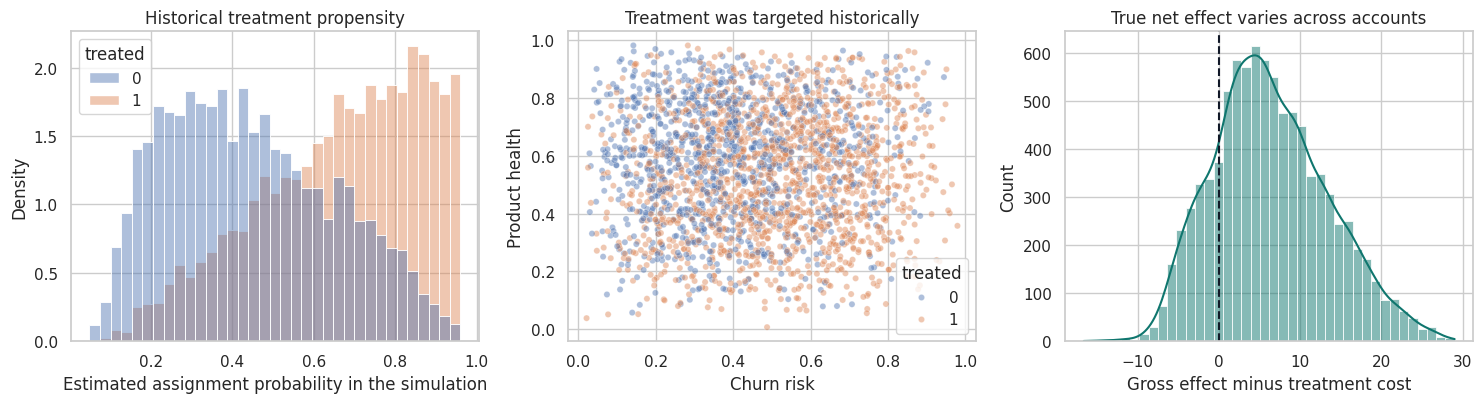

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.histplot(
    data=df,
    x="historical_propensity",
    hue="treated",
    bins=35,
    common_norm=False,
    stat="density",
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("Historical treatment propensity")
axes[0].set_xlabel("Estimated assignment probability in the simulation")

sns.scatterplot(
    data=df.sample(2500, random_state=12),
    x="churn_risk",
    y="product_health",
    hue="treated",
    alpha=0.45,
    s=20,
    ax=axes[1],
)
axes[1].set_title("Treatment was targeted historically")
axes[1].set_xlabel("Churn risk")
axes[1].set_ylabel("Product health")

sns.histplot(df["true_net_effect"], bins=40, kde=True, color="#0f766e", ax=axes[2])
axes[2].axvline(0, color="#111827", linestyle="--", linewidth=1.5)
axes[2].set_title("True net effect varies across accounts")
axes[2].set_xlabel("Gross effect minus treatment cost")

plt.tight_layout()
plt.show()

## 4. The Naive Targeting Trap

One tempting approach is:

1. Predict who will churn or who has low expected value.
2. Target the highest-risk accounts.

That is not necessarily causal. High-risk accounts may have high need, but they may also be difficult to help. A high predicted bad outcome is not the same as a high predicted treatment effect.

Another tempting approach is:

1. Fit a CATE model.
2. Treat everyone with positive estimated CATE.

That is closer, but it can still fail if treatment cost, capacity, and estimation uncertainty are ignored. A good policy-learning workflow separates:

- What is the expected causal benefit?
- What is the cost of acting?
- Which policy class is deployable?
- How will the policy be evaluated before launch?

In [7]:
risk_top_30 = top_fraction_policy(df["churn_risk"], 0.30, require_positive=False)
oracle_top_30 = top_fraction_policy(df["true_net_effect"], 0.30, require_positive=True)
positive_oracle = (df["true_net_effect"] > 0).astype(int)

naive_policy_summary = pd.DataFrame(
    [
        summarize_policy("Treat nobody", np.zeros(len(df), dtype=int)),
        summarize_policy("Treat everybody", np.ones(len(df), dtype=int), df["true_net_effect"]),
        summarize_policy("Top 30% by churn risk", risk_top_30, df["true_net_effect"]),
        summarize_policy("Top 30% by true net effect (oracle)", oracle_top_30, df["true_net_effect"]),
        summarize_policy("Treat all truly positive net effects (oracle)", positive_oracle, df["true_net_effect"]),
    ]
)
naive_policy_summary["true_incremental_gain"] = [
    0.0,
    df["true_net_effect"].mean(),
    np.mean(risk_top_30 * df["true_net_effect"]),
    np.mean(oracle_top_30 * df["true_net_effect"]),
    np.mean(positive_oracle * df["true_net_effect"]),
]
display(naive_policy_summary)

,policy,treatment_rate,avg_score_treated,n_treated,true_incremental_gain
0,Treat nobody,0.000,NaN,0,0.000
1,Treat everybody,1.000,6.401,9000,6.401
2,Top 30% by churn risk,0.300,11.703,2700,3.511
3,Top 30% by true net effect (oracle),0.300,15.015,2700,4.505
4,Treat all truly positive net effects (oracle),0.815,8.577,7334,6.989


The oracle policies are not available in practice because they use the true net treatment effect. They are useful as benchmarks:

- Treat everybody can waste intervention capacity on accounts with low or negative net benefit.
- Risk targeting can be reasonable, but it confuses need with treatability.
- The best constrained policy treats the accounts with the largest positive net effect until capacity runs out.

In an actual project, we need to estimate those net effects from observed data.

## 5. Doubly Robust Scores for Policy Learning

For policy learning, a very useful object is an observation-level doubly robust estimate of each potential outcome:

$$
\Gamma_1
= \hat{\mu}_1(X)
+ \frac{W}{\hat{e}(X)}\{Y-\hat{\mu}_1(X)\}
$$

$$
\Gamma_0
= \hat{\mu}_0(X)
+ \frac{1-W}{1-\hat{e}(X)}\{Y-\hat{\mu}_0(X)\}
$$

where:

- $W$ is treatment.
- $\hat{e}(X)$ estimates the propensity score.
- $\hat{\mu}_1(X)$ estimates $E[Y \mid W=1,X]$.
- $\hat{\mu}_0(X)$ estimates $E[Y \mid W=0,X]$.

The doubly robust treatment-effect score is:

$$
\hat{\tau}_{DR}(X_i) = \Gamma_{1i} - \Gamma_{0i}
$$

For net targeting we subtract cost:

$$
\hat{s}_i = \hat{\tau}_{DR}(X_i) - c(X_i)
$$

These scores can be used to learn a policy and to evaluate candidate policies. Athey and Wager (2021) use doubly robust scores in policy learning with observational data; Zhao et al. (2012) is an important earlier contribution that frames individualized treatment rules through weighted learning.

In [8]:
def crossfit_dr_scores(frame, feature_cols, n_splits=5, seed=5607):
    n = len(frame)
    e_hat = np.zeros(n)
    mu0_hat = np.zeros(n)
    mu1_hat = np.zeros(n)
    fold_id = np.zeros(n, dtype=int)

    propensity_model = HistGradientBoostingClassifier(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=45,
        l2_regularization=0.02,
        random_state=seed,
    )
    outcome_model = HistGradientBoostingRegressor(
        max_iter=220,
        learning_rate=0.04,
        min_samples_leaf=45,
        l2_regularization=0.02,
        random_state=seed + 1,
    )

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (train_idx, test_idx) in enumerate(kfold.split(frame), start=1):
        train = frame.iloc[train_idx]
        test = frame.iloc[test_idx]

        p_model = clone(propensity_model)
        p_model.fit(train[feature_cols], train["treated"])
        e_hat[test_idx] = np.clip(p_model.predict_proba(test[feature_cols])[:, 1], 0.03, 0.97)

        treated_train = train[train["treated"] == 1]
        control_train = train[train["treated"] == 0]

        m1 = clone(outcome_model)
        m0 = clone(outcome_model)
        m1.fit(treated_train[feature_cols], treated_train["outcome"])
        m0.fit(control_train[feature_cols], control_train["outcome"])

        mu1_hat[test_idx] = m1.predict(test[feature_cols])
        mu0_hat[test_idx] = m0.predict(test[feature_cols])
        fold_id[test_idx] = fold

    w = frame["treated"].to_numpy()
    y = frame["outcome"].to_numpy()
    gamma1 = mu1_hat + (w / e_hat) * (y - mu1_hat)
    gamma0 = mu0_hat + ((1 - w) / (1 - e_hat)) * (y - mu0_hat)
    tau_dr = gamma1 - gamma0
    net_dr = tau_dr - frame["treatment_cost"].to_numpy()

    diagnostics = pd.DataFrame(
        {
            "fold": fold_id,
            "e_hat": e_hat,
            "mu0_hat": mu0_hat,
            "mu1_hat": mu1_hat,
            "gamma0": gamma0,
            "gamma1": gamma1,
            "tau_dr": tau_dr,
            "net_dr": net_dr,
        },
        index=frame.index,
    )
    return diagnostics


dr = crossfit_dr_scores(df, feature_cols)
df_dr = pd.concat([df, dr], axis=1)

diagnostic_table = pd.DataFrame(
    {
        "diagnostic": [
            "Propensity AUC",
            "Outcome R2, treated potential outcome score",
            "Outcome R2, untreated potential outcome score",
            "RMSE of DR gross effect vs simulation truth",
            "Correlation of DR net score with true net effect",
            "Share of estimated propensities below 0.08",
            "Share of estimated propensities above 0.92",
        ],
        "value": [
            roc_auc_score(df_dr["treated"], df_dr["e_hat"]),
            r2_score(df_dr["outcome"], df_dr["mu1_hat"]),
            r2_score(df_dr["outcome"], df_dr["mu0_hat"]),
            np.sqrt(mean_squared_error(df_dr["gross_treatment_effect"], df_dr["tau_dr"])),
            np.corrcoef(df_dr["net_dr"], df_dr["true_net_effect"])[0, 1],
            (df_dr["e_hat"] < 0.08).mean(),
            (df_dr["e_hat"] > 0.92).mean(),
        ],
    }
)
display(diagnostic_table)

,diagnostic,value
0,Propensity AUC,0.758
1,"Outcome R2, treated potential outcome score",0.612
2,"Outcome R2, untreated potential outcome score",0.288
3,RMSE of DR gross effect vs simulation truth,24.498
4,Correlation of DR net score with true net effect,0.265
5,Share of estimated propensities below 0.08,0.006
6,Share of estimated propensities above 0.92,0.054


The nuisance diagnostics are not the final answer, but they determine how much trust we should put in the policy scores.

The propensity model tells us how strongly historical assignment depended on observed covariates. Extremely small or large propensities create overlap problems: the data contain few comparable examples for some actions in some regions of covariate space.

The DR net score is noisy at the individual level. It should usually be used to learn a smoother policy or rank broad segments, not to claim that a single account has a precisely estimated effect.

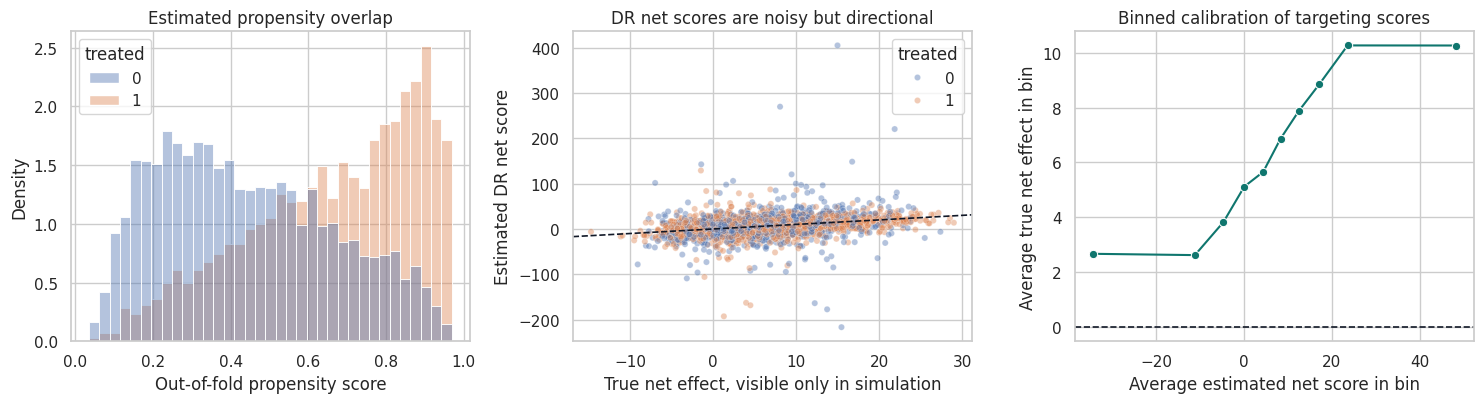

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.histplot(
    data=df_dr,
    x="e_hat",
    hue="treated",
    bins=35,
    stat="density",
    common_norm=False,
    alpha=0.42,
    ax=axes[0],
)
axes[0].set_title("Estimated propensity overlap")
axes[0].set_xlabel("Out-of-fold propensity score")

sns.scatterplot(
    data=df_dr.sample(2500, random_state=8),
    x="true_net_effect",
    y="net_dr",
    hue="treated",
    alpha=0.42,
    s=20,
    ax=axes[1],
)
axes[1].axline((0, 0), slope=1, color="#111827", linestyle="--", linewidth=1.2)
axes[1].set_title("DR net scores are noisy but directional")
axes[1].set_xlabel("True net effect, visible only in simulation")
axes[1].set_ylabel("Estimated DR net score")

calibration = (
    df_dr.assign(score_bin=pd.qcut(df_dr["net_dr"], 10, labels=False, duplicates="drop"))
    .groupby("score_bin", as_index=False)
    .agg(avg_dr_score=("net_dr", "mean"), avg_true_net=("true_net_effect", "mean"), n=("account_id", "size"))
)
sns.lineplot(data=calibration, x="avg_dr_score", y="avg_true_net", marker="o", color="#0f766e", ax=axes[2])
axes[2].axhline(0, color="#111827", linestyle="--", linewidth=1.2)
axes[2].set_title("Binned calibration of targeting scores")
axes[2].set_xlabel("Average estimated net score in bin")
axes[2].set_ylabel("Average true net effect in bin")

plt.tight_layout()
plt.show()

## 6. Honest Policy Splitting

Policy learning has a subtle overfitting risk. If we use the same data to:

1. Estimate causal scores.
2. Search across many policies.
3. Report the best policy value.

then the selected policy can look too good.

A simple applied workflow is:

1. Estimate nuisance functions with cross-fitting.
2. Split accounts into a policy-training sample and a policy-evaluation sample.
3. Learn the policy on the training sample.
4. Evaluate the selected policy on the held-out evaluation sample.

For high-stakes deployments, use nested cross-fitting or a fresh experiment. Here we use a train/evaluation split to keep the notebook readable.

In [10]:
train_idx, eval_idx = train_test_split(
    df_dr.index,
    test_size=0.40,
    random_state=5610,
    stratify=df_dr["treated"],
)
policy_train = df_dr.loc[train_idx].copy()
policy_eval = df_dr.loc[eval_idx].copy()

len(policy_train), len(policy_eval), policy_train["treated"].mean(), policy_eval["treated"].mean()

(5400, 3600, np.float64(0.5662962962962963), np.float64(0.5661111111111111))

## 7. Learning Candidate Policies

We will compare several policies:

- Treat nobody.
- Treat everybody.
- Treat the top 30% by churn risk.
- Treat the top 30% by a flexible learned DR net-benefit score.
- Treat the top 30% by a shallow decision-tree score.
- Treat the top 30% by the true net effect, which is an oracle benchmark available only in simulation.

The flexible score may perform better, but the shallow tree is easier to communicate and operationalize. That tradeoff is common in industry: a slightly lower estimated value may be worth it if the rule can be explained, audited, implemented, and monitored.

In [11]:
budget_rate = 0.30

flex_policy_model = HistGradientBoostingRegressor(
    max_iter=180,
    learning_rate=0.045,
    min_samples_leaf=50,
    l2_regularization=0.04,
    random_state=5611,
)
tree_policy_model = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=170,
    random_state=5612,
)

flex_policy_model.fit(policy_train[feature_cols], policy_train["net_dr"])
tree_policy_model.fit(policy_train[feature_cols], policy_train["net_dr"])

policy_eval["flex_score"] = flex_policy_model.predict(policy_eval[feature_cols])
policy_eval["tree_score"] = tree_policy_model.predict(policy_eval[feature_cols])
policy_eval["risk_score_policy_score"] = policy_eval["churn_risk"]

candidate_policies = {
    "Treat nobody": np.zeros(len(policy_eval), dtype=int),
    "Treat everybody": np.ones(len(policy_eval), dtype=int),
    "Top 30% by churn risk": top_fraction_policy(policy_eval["risk_score_policy_score"], budget_rate, require_positive=False),
    "Top 30% by flexible DR net score": top_fraction_policy(policy_eval["flex_score"], budget_rate, require_positive=True),
    "Top 30% by shallow tree score": top_fraction_policy(policy_eval["tree_score"], budget_rate, require_positive=True),
    "Top 30% by true net effect (oracle)": top_fraction_policy(policy_eval["true_net_effect"], budget_rate, require_positive=True),
}

pd.DataFrame(
    [
        summarize_policy(name, policy, policy_eval["true_net_effect"])
        for name, policy in candidate_policies.items()
    ]
)

,policy,treatment_rate,avg_score_treated,n_treated
0,Treat nobody,0.000,NaN,0
1,Treat everybody,1.000,6.321,3600
2,Top 30% by churn risk,0.300,11.460,1080
3,Top 30% by flexible DR net score,0.300,12.807,1080
4,Top 30% by shallow tree score,0.340,12.977,1223
5,Top 30% by true net effect (oracle),0.300,14.909,1080


## 8. Doubly Robust Policy Evaluation

For a candidate policy $\pi$, a doubly robust estimate of net policy value is:

$$
\hat{V}_c(\pi)
= \frac{1}{n}\sum_i
\left[
\pi(X_i)\{\Gamma_{1i}-c(X_i)\}
+ (1-\pi(X_i))\Gamma_{0i}
\right]
$$

The incremental gain over treating nobody is:

$$
\hat{G}_c(\pi)
= \frac{1}{n}\sum_i
\pi(X_i)\{\Gamma_{1i}-\Gamma_{0i}-c(X_i)\}
$$

This is not just a prediction metric. It is an estimate of the counterfactual value that would have occurred if the policy had been used for the evaluation sample.

In [12]:
def evaluate_policy(frame, policy):
    policy = np.asarray(policy)
    gamma1 = frame["gamma1"].to_numpy()
    gamma0 = frame["gamma0"].to_numpy()
    cost = frame["treatment_cost"].to_numpy()

    dr_value_contribution = policy * (gamma1 - cost) + (1 - policy) * gamma0
    dr_gain_contribution = policy * (gamma1 - gamma0 - cost)

    true_value_contribution = frame["baseline_value"].to_numpy() + policy * frame["gross_treatment_effect"].to_numpy() - policy * cost
    true_gain_contribution = policy * frame["true_net_effect"].to_numpy()

    se_gain = np.std(dr_gain_contribution, ddof=1) / np.sqrt(len(frame))

    return {
        "treatment_rate": policy.mean(),
        "dr_incremental_gain": dr_gain_contribution.mean(),
        "dr_gain_ci_low": dr_gain_contribution.mean() - 1.96 * se_gain,
        "dr_gain_ci_high": dr_gain_contribution.mean() + 1.96 * se_gain,
        "dr_net_policy_value": dr_value_contribution.mean(),
        "true_incremental_gain": true_gain_contribution.mean(),
        "true_net_policy_value": true_value_contribution.mean(),
    }


policy_results = pd.DataFrame(
    [
        {"policy": name, **evaluate_policy(policy_eval, policy)}
        for name, policy in candidate_policies.items()
    ]
).sort_values("dr_incremental_gain", ascending=False)

display(policy_results)

,policy,treatment_rate,dr_incremental_gain,dr_gain_ci_low,dr_gain_ci_high,dr_net_policy_value,true_incremental_gain,true_net_policy_value
1,Treat everybody,1.000,5.828,5.038,6.617,78.537,6.321,78.845
5,Top 30% by true net effect (oracle),0.300,4.165,3.636,4.694,76.874,4.473,76.997
4,Top 30% by shallow tree score,0.340,4.024,3.503,4.545,76.733,4.409,76.933
3,Top 30% by flexible DR net score,0.300,3.529,3.013,4.044,76.238,3.842,76.367
2,Top 30% by churn risk,0.300,3.169,2.657,3.682,75.878,3.438,75.963
0,Treat nobody,0.000,0.000,0.000,0.000,72.709,0.000,72.525


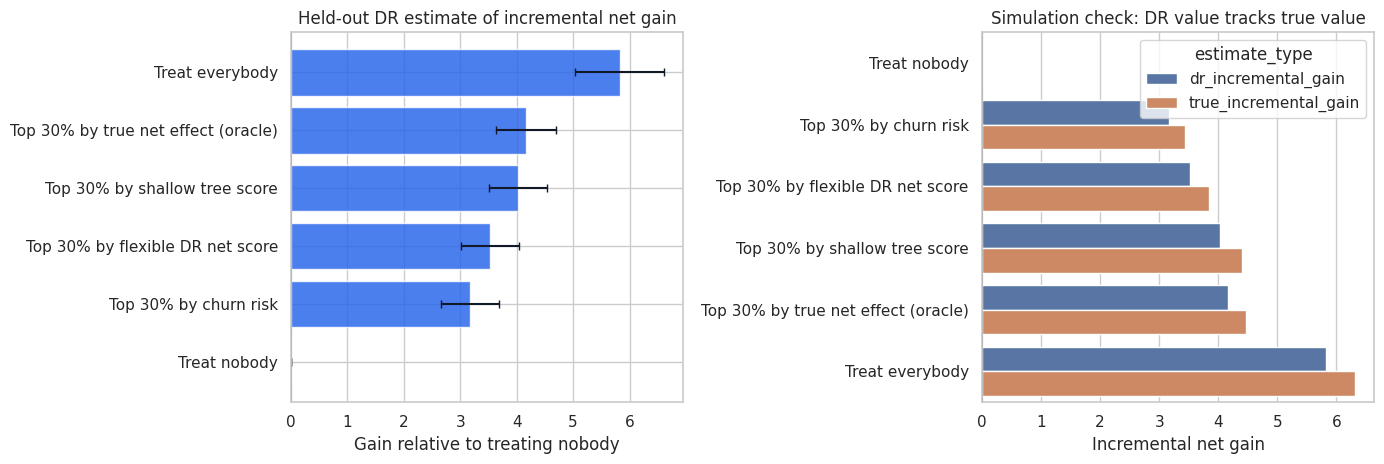

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

plot_data = policy_results.sort_values("dr_incremental_gain")
axes[0].barh(plot_data["policy"], plot_data["dr_incremental_gain"], color="#2563eb", alpha=0.82)
axes[0].errorbar(
    x=plot_data["dr_incremental_gain"],
    y=np.arange(len(plot_data)),
    xerr=[
        plot_data["dr_incremental_gain"] - plot_data["dr_gain_ci_low"],
        plot_data["dr_gain_ci_high"] - plot_data["dr_incremental_gain"],
    ],
    fmt="none",
    ecolor="#111827",
    capsize=3,
)
axes[0].axvline(0, color="#111827", linewidth=1.1)
axes[0].set_title("Held-out DR estimate of incremental net gain")
axes[0].set_xlabel("Gain relative to treating nobody")

comparison = policy_results.melt(
    id_vars="policy",
    value_vars=["dr_incremental_gain", "true_incremental_gain"],
    var_name="estimate_type",
    value_name="incremental_gain",
)
sns.barplot(
    data=comparison,
    y="policy",
    x="incremental_gain",
    hue="estimate_type",
    order=plot_data["policy"],
    ax=axes[1],
)
axes[1].axvline(0, color="#111827", linewidth=1.1)
axes[1].set_title("Simulation check: DR value tracks true value")
axes[1].set_xlabel("Incremental net gain")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

The flexible policy should usually beat a simple risk policy because it is trying to target causal net benefit, not just baseline risk. The shallow tree may give up some value in exchange for interpretability.

The oracle is a ceiling. If a learned policy is close to the oracle, that is encouraging. If it is far below the oracle, the gap tells us there may be room for better effect estimation, better policy classes, or better exploration data.

## 9. Targeting Curves

A single budget level can hide the operational tradeoff. A targeting curve evaluates the policy as capacity changes.

For each treatment fraction $q$, we treat the top $q$ fraction by the policy score and estimate the incremental gain. This answers questions like:

- How much value is captured by the first 10% of accounts?
- Does value flatten after 30%?
- At what point does marginal targeting become unattractive?
- Is the flexible policy consistently better than a risk-only rule?

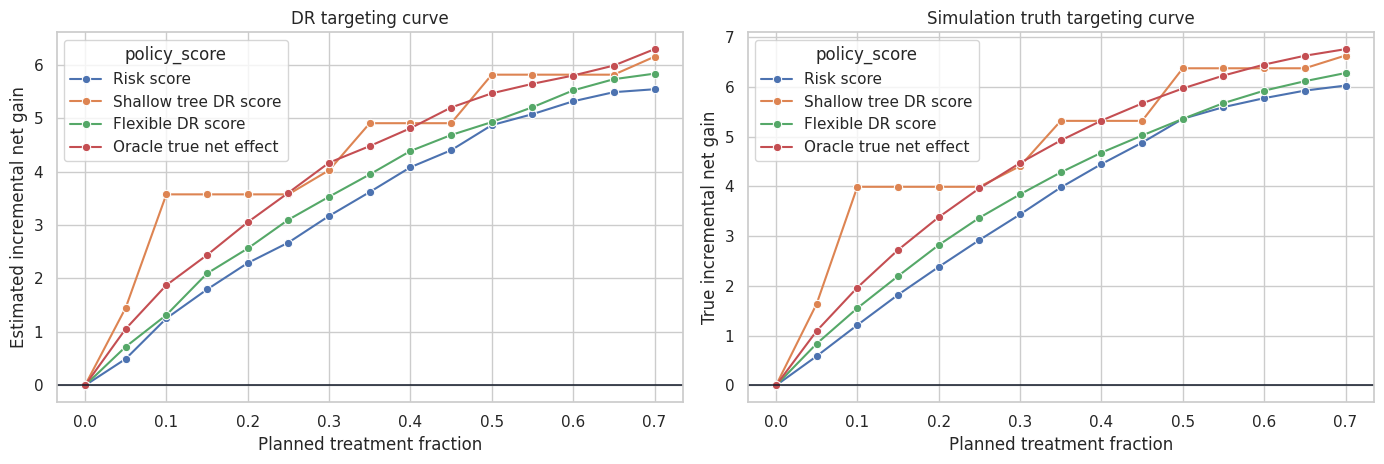

In [14]:
def policy_curve(frame, score_col, fractions, label, require_positive=True):
    rows = []
    for frac in fractions:
        policy = top_fraction_policy(frame[score_col], frac, require_positive=require_positive)
        evaluated = evaluate_policy(frame, policy)
        rows.append(
            {
                "policy_score": label,
                "target_fraction": frac,
                "actual_treatment_rate": evaluated["treatment_rate"],
                "dr_incremental_gain": evaluated["dr_incremental_gain"],
                "true_incremental_gain": evaluated["true_incremental_gain"],
            }
        )
    return pd.DataFrame(rows)


fractions = np.linspace(0, 0.70, 15)
curve_df = pd.concat(
    [
        policy_curve(policy_eval, "risk_score_policy_score", fractions, "Risk score", require_positive=False),
        policy_curve(policy_eval, "tree_score", fractions, "Shallow tree DR score", require_positive=True),
        policy_curve(policy_eval, "flex_score", fractions, "Flexible DR score", require_positive=True),
        policy_curve(policy_eval, "true_net_effect", fractions, "Oracle true net effect", require_positive=True),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.lineplot(
    data=curve_df,
    x="target_fraction",
    y="dr_incremental_gain",
    hue="policy_score",
    marker="o",
    ax=axes[0],
)
axes[0].axhline(0, color="#111827", linewidth=1.1)
axes[0].set_title("DR targeting curve")
axes[0].set_xlabel("Planned treatment fraction")
axes[0].set_ylabel("Estimated incremental net gain")

sns.lineplot(
    data=curve_df,
    x="target_fraction",
    y="true_incremental_gain",
    hue="policy_score",
    marker="o",
    ax=axes[1],
)
axes[1].axhline(0, color="#111827", linewidth=1.1)
axes[1].set_title("Simulation truth targeting curve")
axes[1].set_xlabel("Planned treatment fraction")
axes[1].set_ylabel("True incremental net gain")

plt.tight_layout()
plt.show()

Targeting curves are often more useful than one headline number. They reveal whether a policy is robust to capacity changes and whether the top-ranked cases are meaningfully better than later cases.

In an industry readout, this plot naturally becomes a capacity planning tool: if the team can support only 15% of accounts, estimate the value at 15%; if leadership funds more capacity, show the expected gain at 25% or 35%.

## 10. Interpretable Policy Rules

Black-box policy scores can be useful for ranking, but many organizations need something easier to inspect:

- Compliance needs to know why customers are selected.
- Operators need to know how the rule maps to workflow.
- Product teams need to understand which customer problems are being targeted.
- Executives need to see that the rule is not merely rediscovering historical bias.

A shallow decision tree is one simple interpretable policy class. It is not always optimal, but it can be a strong baseline for deployment.

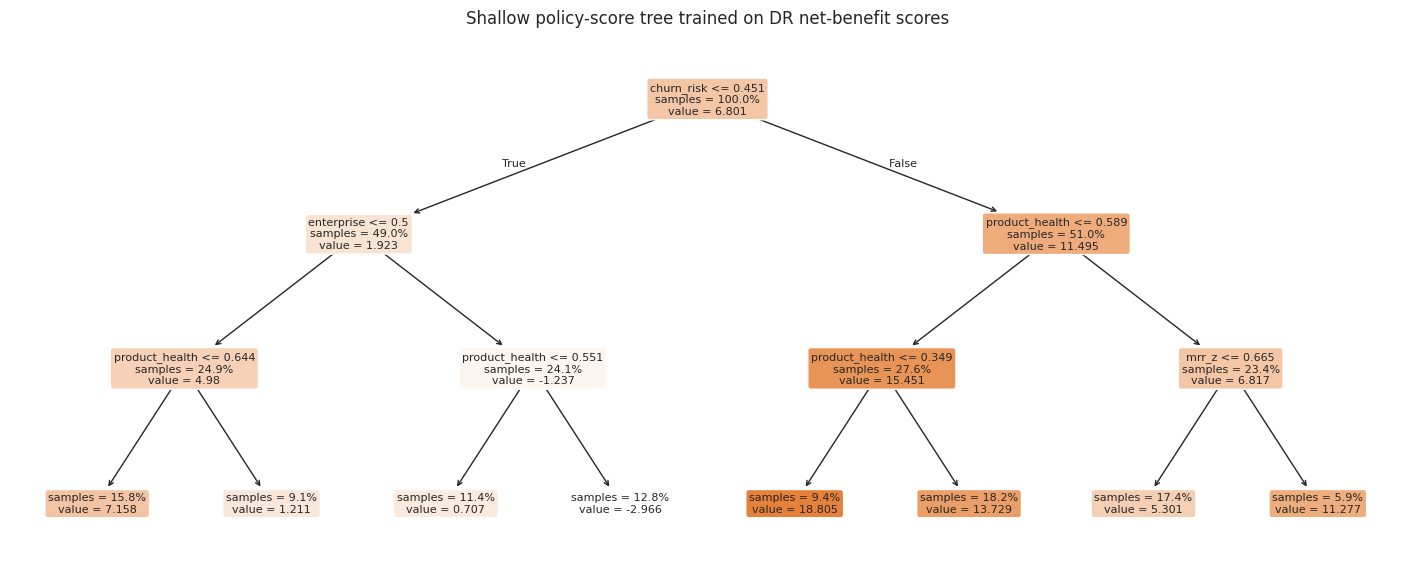

In [15]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    tree_policy_model,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Shallow policy-score tree trained on DR net-benefit scores")
plt.show()

In [16]:
policy_eval["tree_policy"] = candidate_policies["Top 30% by shallow tree score"]
policy_eval["flex_policy"] = candidate_policies["Top 30% by flexible DR net score"]

segment_table = (
    policy_eval.assign(
        risk_band=pd.qcut(policy_eval["churn_risk"], 4, labels=["Low risk", "Med-low risk", "Med-high risk", "High risk"]),
        health_band=pd.qcut(policy_eval["product_health"], 4, labels=["Low health", "Med-low health", "Med-high health", "High health"]),
    )
    .groupby(["risk_band", "health_band"], observed=True)
    .agg(
        n=("account_id", "size"),
        avg_true_net=("true_net_effect", "mean"),
        avg_dr_net=("net_dr", "mean"),
        tree_treat_rate=("tree_policy", "mean"),
        flex_treat_rate=("flex_policy", "mean"),
    )
    .reset_index()
)

display(segment_table.sort_values("avg_dr_net", ascending=False).head(10))

,risk_band,health_band,n,avg_true_net,avg_dr_net,tree_treat_rate,flex_treat_rate
12,High risk,Low health,217,18.195,18.218,1.000,0.756
13,High risk,Med-low health,240,14.316,13.263,1.000,0.667
8,Med-high risk,Low health,218,15.922,12.886,1.000,0.798
9,Med-high risk,Med-low health,221,11.428,9.410,1.000,0.638
14,High risk,Med-high health,224,9.459,8.223,0.348,0.446
10,Med-high risk,Med-high health,222,8.068,7.027,0.401,0.279
4,Med-low risk,Low health,227,6.815,6.453,0.066,0.216
11,Med-high risk,High health,239,4.135,6.094,0.297,0.155
5,Med-low risk,Med-low health,202,3.830,4.207,0.050,0.124
6,Med-low risk,Med-high health,244,2.543,4.031,0.016,0.082


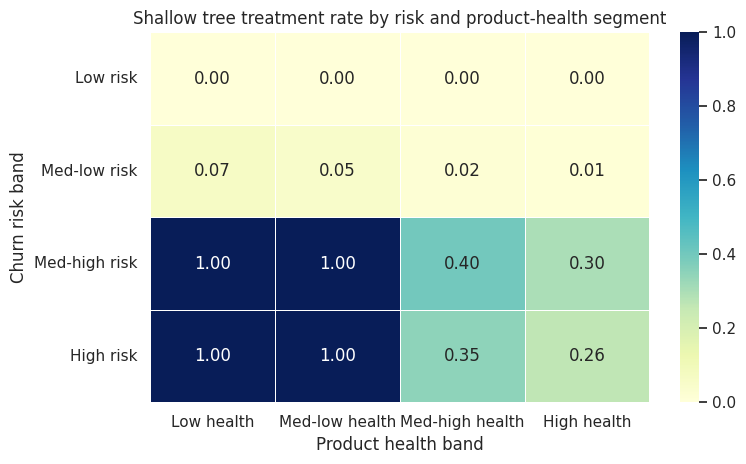

In [17]:
heat = segment_table.pivot(index="risk_band", columns="health_band", values="tree_treat_rate")
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Shallow tree treatment rate by risk and product-health segment")
ax.set_xlabel("Product health band")
ax.set_ylabel("Churn risk band")
plt.tight_layout()
plt.show()

The segment table is a bridge between causal modeling and operational decision-making. It helps answer:

- Which segments does the policy emphasize?
- Are those segments plausible from a product or customer-success perspective?
- Are high-treatment segments actually high estimated net benefit?
- Are there segments with low overlap or policy risk that need separate review?

This is where a causal ML project becomes an organizational artifact rather than a notebook-only exercise.

## 11. Policy Regret

Policy regret compares a candidate policy to the best policy in a class or to an oracle benchmark:

$$
Regret(\pi) = V(\pi^*) - V(\pi)
$$

In simulation, we can compare to the true top-30% oracle. In real life, we usually compare to:

- The best policy found in an interpretable policy class.
- A held-out evaluation estimate of the best candidate.
- A randomized pilot or A/B test.
- A conservative baseline such as current business rules.

Regret is useful because it reframes the question from "is this effect statistically significant?" to "how much value are we leaving on the table by using this rule?"

In [18]:
oracle_gain = policy_results.loc[
    policy_results["policy"] == "Top 30% by true net effect (oracle)",
    "true_incremental_gain",
].iloc[0]

regret_table = policy_results.copy()
regret_table["true_regret_vs_oracle_top_30"] = oracle_gain - regret_table["true_incremental_gain"]
regret_table = regret_table[
    [
        "policy",
        "treatment_rate",
        "dr_incremental_gain",
        "true_incremental_gain",
        "true_regret_vs_oracle_top_30",
    ]
].sort_values("true_regret_vs_oracle_top_30")

display(regret_table)

,policy,treatment_rate,dr_incremental_gain,true_incremental_gain,true_regret_vs_oracle_top_30
1,Treat everybody,1.000,5.828,6.321,-1.848
5,Top 30% by true net effect (oracle),0.300,4.165,4.473,0.000
4,Top 30% by shallow tree score,0.340,4.024,4.409,0.064
3,Top 30% by flexible DR net score,0.300,3.529,3.842,0.631
2,Top 30% by churn risk,0.300,3.169,3.438,1.035
0,Treat nobody,0.000,0.000,0.000,4.473


## 12. Practical Guardrails

Policy learning is powerful, but it can fail in very practical ways.

Important guardrails:

- Identification first: the policy is only as credible as the causal identification strategy.
- No post-treatment variables: do not use features that are caused by the historical treatment.
- Overlap checks: avoid recommending actions in regions with little or no support.
- Honest evaluation: evaluate a selected policy on held-out data or through a new experiment.
- Cost accounting: include marginal cost, not just gross outcome lift.
- Capacity constraints: match the policy to what the business can actually deliver.
- Monitoring: measure drift in covariates, propensities, treatment rates, outcomes, and realized value.
- Human review: inspect high-impact segments before automation.

The most dangerous deployment is a policy that looks precise but is actually extrapolating beyond the data.

In [19]:
review_frame = policy_eval.assign(
    selected_flex=candidate_policies["Top 30% by flexible DR net score"],
    selected_tree=candidate_policies["Top 30% by shallow tree score"],
    low_overlap=(policy_eval["e_hat"] < 0.08) | (policy_eval["e_hat"] > 0.92),
)

flex_selected = review_frame["selected_flex"] == 1
tree_selected = review_frame["selected_tree"] == 1

overlap_review = pd.DataFrame(
    {
        "metric": [
            "Flexible policy treatment rate",
            "Tree policy treatment rate",
            "Low-overlap share overall",
            "Low-overlap share among flexible-policy selected accounts",
            "Low-overlap share among tree-policy selected accounts",
        ],
        "value": [
            review_frame["selected_flex"].mean(),
            review_frame["selected_tree"].mean(),
            review_frame["low_overlap"].mean(),
            review_frame.loc[flex_selected, "low_overlap"].mean(),
            review_frame.loc[tree_selected, "low_overlap"].mean(),
        ],
    }
)

display(overlap_review)

,metric,value
0,Flexible policy treatment rate,0.300
1,Tree policy treatment rate,0.340
2,Low-overlap share overall,0.060
3,Low-overlap share among flexible-policy select...,0.097
4,Low-overlap share among tree-policy selected a...,0.128


## 13. Industry Readout Template

A professional policy-learning readout should be decision-oriented:

1. Decision: which accounts should receive the retention intervention next quarter?
2. Estimand: net incremental value, equal to treatment effect minus intervention cost.
3. Identification: assumes no unobserved confounding after pre-treatment customer features.
4. Policy class: flexible score policy and shallow interpretable tree policy.
5. Capacity: main recommendation shown at 30% treatment capacity, with targeting curves for other capacities.
6. Evaluation: held-out doubly robust policy value with uncertainty intervals.
7. Diagnostics: overlap, nuisance model quality, score calibration, and segment review.
8. Recommendation: choose the highest-value policy that satisfies operational and governance constraints.
9. Next step: run a randomized pilot or staged rollout to validate realized value.

In [20]:
best_non_oracle = (
    policy_results[~policy_results["policy"].str.contains("oracle")]
    .sort_values("dr_incremental_gain", ascending=False)
    .iloc[0]
)

readout = pd.DataFrame(
    {
        "item": [
            "Recommended non-oracle policy",
            "Treatment rate",
            "Held-out DR incremental net gain",
            "Approximate 95% CI",
            "Simulation true incremental gain",
            "Primary business interpretation",
            "Main caution",
        ],
        "value": [
            best_non_oracle["policy"],
            f"{best_non_oracle['treatment_rate']:.1%}",
            f"{best_non_oracle['dr_incremental_gain']:.2f}",
            f"[{best_non_oracle['dr_gain_ci_low']:.2f}, {best_non_oracle['dr_gain_ci_high']:.2f}]",
            f"{best_non_oracle['true_incremental_gain']:.2f}",
            "Target customer-success capacity toward accounts with high estimated net causal benefit.",
            "Validate with a randomized pilot before full automation.",
        ],
    }
)

display(readout)

,item,value
0,Recommended non-oracle policy,Treat everybody
1,Treatment rate,100.0%
2,Held-out DR incremental net gain,5.83
3,Approximate 95% CI,"[5.04, 6.62]"
4,Simulation true incremental gain,6.32
5,Primary business interpretation,Target customer-success capacity toward accoun...
6,Main caution,Validate with a randomized pilot before full a...


## Key Takeaways

- CATE estimation and policy learning are related but not identical.
- A treatment policy maps covariates to actions.
- Policy value is the expected outcome if that rule were deployed.
- Net policy value should subtract intervention costs.
- Capacity constraints turn policy learning into a ranking or constrained optimization problem.
- Doubly robust scores can support both policy learning and policy evaluation.
- Honest evaluation is essential because policy selection can overfit.
- Interpretable policy classes may be preferable when the deployment environment requires transparency.
- Targeting curves are often the best way to communicate value under changing operational capacity.
- A deployed policy should be monitored like a production decision system, not just like a predictive model.

## References

Athey, S., & Wager, S. (2021). Policy learning with observational data. *Econometrica, 89*(1), 133-161. https://doi.org/10.3982/ecta15732

Kallus, N. (2020). More efficient policy learning via optimal retargeting. *Journal of the American Statistical Association, 116*(534), 646-658. https://doi.org/10.1080/01621459.2020.1788948

Kitagawa, T., & Tetenov, A. (2018). Who should be treated? Empirical welfare maximization methods for treatment choice. *Econometrica, 86*(2), 591-616. https://doi.org/10.3982/ecta13288

Zhao, Y. Q., Zeng, D., Rush, A. J., & Kosorok, M. R. (2012). Estimating individualized treatment rules using outcome weighted learning. *Journal of the American Statistical Association, 107*(499), 1106-1118. https://doi.org/10.1080/01621459.2012.695674